## Preprocess the data for 2D barotropic simulations using 3D interpolated data from GLORYS

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import xarray as xr
from pathlib import Path
import importlib

sys.path.append(os.path.abspath('../scripts'))
import ocean_analysis as oa 
importlib.reload(oa)


<module 'ocean_analysis' from 'c:\\Users\\Jelle Gortemaker\\Documents\\Thesis\\OGCM\\scripts\\ocean_analysis.py'>

MLD statistics [m]
Mean:   60.64
Median: 60.85


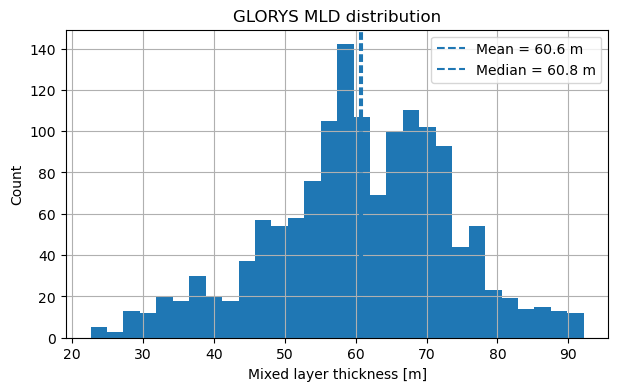

In [ ]:
GLORYS_file = "../data/input/GPGP_jan2020_3D_21.5_24.5_141.6_138.4.nc"

MITgcm_interp_file = "../data/input/MITgcm_spinup_256x256_jan2020.nc"
output_file = "../data/processed/MITgcm_spinup_256x256_jan2020_1layer.nc"
delR = [60.0]



ds = xr.open_dataset(GLORYS_file)
mld = ds["mlotst"]

for tdim in ["time", "time_counter", "t"]:
    if tdim in mld.dims:
        mld = mld.mean(dim=tdim)
        break

values = mld.values
values = values[np.isfinite(values)]

print("MLD statistics [m]")
print(f"Mean:   {np.mean(values):.2f}")
print(f"Median: {np.median(values):.2f}")

plt.figure(figsize=(7, 4))
plt.hist(values, bins=30)
plt.axvline(np.mean(values), linestyle="--", label=f"Mean = {np.mean(values):.1f} m")
plt.axvline(np.median(values), linestyle="--", label=f"Median = {np.median(values):.1f} m")
plt.xlabel("Mixed layer thickness [m]")
plt.ylabel("Count")
plt.title("GLORYS MLD distribution")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# oa.spinup_to_baro1_bin(
#     input_nc=MITgcm_interp_file,
#     output_file="../data/processed/MITgcm_spinup_256x256_jan2020_1layer.nc",
#     dtype=">f4",
# )

Saved u velocity to: ..\data\processed\MITgcm_spinup_256x256_jan2020_1layer_uvel.bin
Saved v velocity to: ..\data\processed\MITgcm_spinup_256x256_jan2020_1layer_vvel.bin
u shape written: (1, 512, 512)
v shape written: (1, 512, 512)
Use readBinaryPrec = 32 in MITgcm.


In [ ]:
oa.slice_vertical_layers_delR(
    input_nc=MITgcm_interp_file,
    output_nc=output_file,
    delR=delR,
    depth_dim="z",
    variables=["u_mit", "v_mit"],
    time_index=0,
    dtype=">f4",
    Nx=512,
    Ny=512,
)

ValueError: Could not infer exactly two horizontal dimensions from None. DataArray dims are ('Zmd000002', 'T', 'Y', 'Xp1'), got horizontal dims ['T', 'Y', 'Xp1'].